# Lab 5: Phân loại văn bản với Mạng Nơ-ron hồi quy (RNN/LSTM)

## 0. Thiết lập môi trường và tải dữ liệu 

In [1]:
import pandas as pd 

df_train = pd.read_csv(r"D:\NLP_DL\data\hwu\hwu\train.csv")
df_val = pd.read_csv(r"D:\NLP_DL\data\hwu\hwu\val.csv")
df_test = pd.read_csv(r"D:\NLP_DL\data\hwu\hwu\test.csv")

print("Train shape:", df_train.shape)
print("Validation shape:", df_val.shape)
print("Test shape:", df_test.shape)
df_train.head()

Train shape: (8954, 2)
Validation shape: (1076, 2)
Test shape: (1076, 2)


,text,category
0,what alarms do i have set right now,alarm_query
1,checkout today alarm of meeting,alarm_query
2,report alarm settings,alarm_query
3,see see for me the alarms that you have set to...,alarm_query
4,is there an alarm for ten am,alarm_query


In [2]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(pd.concat([df_train['category'], df_val['category'], df_test['category']]))

df_train['category_enc'] = le.transform(df_train['category'])
df_val['category_enc'] = le.transform(df_val['category'])
df_test['category_enc'] = le.transform(df_test['category'])

num_classes = len(le.classes_)


## 1. (warm up) Pipline TF-IDF + Logistic Regression 

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, f1_score

# 1. Tạo một pipeline với TfidfVectorizer và LogisticRegression
tfidf_lr_pipeline = make_pipeline(
    TfidfVectorizer(max_features=5000),
    LogisticRegression(max_iter=1000)
)

# 2. Huấn luyện mô hình trên tập huấn luyện
tfidf_lr_pipeline.fit(df_train['text'], df_train['category_enc'])

# 3. Đánh giá mô hình trên tập kiểm tra
y_pred = tfidf_lr_pipeline.predict(df_test['text'])
print(classification_report(df_test['category_enc'], y_pred, target_names=[str(label) for label in le.classes_]))

f1_macro = f1_score(df_test['category_enc'], y_pred, average='macro')
print("TF-IDF + Logistic Regression F1 Macro:", f1_macro)

                          precision    recall  f1-score   support

             alarm_query       0.90      0.95      0.92        19
            alarm_remove       1.00      0.73      0.84        11
               alarm_set       0.77      0.89      0.83        19
       audio_volume_down       1.00      0.75      0.86         8
       audio_volume_mute       0.92      0.80      0.86        15
         audio_volume_up       0.93      1.00      0.96        13
          calendar_query       0.45      0.53      0.49        19
         calendar_remove       0.89      0.89      0.89        19
            calendar_set       0.87      0.68      0.76        19
          cooking_recipe       0.59      0.68      0.63        19
        datetime_convert       0.67      0.75      0.71         8
          datetime_query       0.74      0.89      0.81        19
        email_addcontact       0.78      0.88      0.82         8
             email_query       0.83      0.79      0.81        19
      ema

## 2. (Warm up) Pipeline Word2Vec(Trung bình) + Dense Layer 

In [29]:
import numpy as np 
from gensim.models import Word2Vec
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Huấn luyện mô hình Word2Vec trên tập huấn luyện
sentences = [text.split() for text in df_train['text']]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4, epochs=50)

# 2. Hàm để chuyển đổi câu thành vector trung bình của các từ
def sentence_to_avg_vector(sentence, model):
    words = sentence.split()
    word_vectors = [model.wv[word] for word in words if word in model.wv]
    if len(word_vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(word_vectors, axis=0)

# 3. Tạo dữ liệu train/val/test X_train_avg, X_val_avg, X_test_avg
X_train_avg = np.array([sentence_to_avg_vector(text, w2v_model) for text in df_train['text']])
X_val_avg = np.array([sentence_to_avg_vector(text, w2v_model) for text in df_val['text']])
X_test_avg = np.array([sentence_to_avg_vector(text, w2v_model) for text in df_test['text']])


# 4. Xây dựng mô hình Sequential của Keras 
model = Sequential([
    Dense(128, activation='relu', input_shape=(w2v_model.vector_size,)),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# 5. Copile, huan luyen va danh gia mo hinh
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_avg, df_train['category_enc'], epochs=20, batch_size=16,
              validation_data=(X_val_avg, df_val['category_enc']))

loss, acc = model.evaluate(X_test_avg, df_test['category_enc'])
y_pred = np.argmax(model.predict(X_test_avg), axis=1)
f1_macro = f1_score(df_test['category_enc'], y_pred, average='macro')
print("Word2Vec (Avg) + Dense F1 Macro:", f1_macro)

Epoch 1/20


d:\NLP_DL\env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5127 - loss: 2.0678 - val_accuracy: 0.7296 - val_loss: 1.0928
Epoch 2/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7078 - loss: 1.0568 - val_accuracy: 0.7416 - val_loss: 0.8802
Epoch 3/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7458 - loss: 0.9004 - val_accuracy: 0.7760 - val_loss: 0.7952
Epoch 4/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7685 - loss: 0.8265 - val_accuracy: 0.7918 - val_loss: 0.7577
Epoch 5/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7780 - loss: 0.7800 - val_accuracy: 0.7928 - val_loss: 0.7323
Epoch 6/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7884 - loss: 0.7353 - val_accuracy: 0.7983 - val_loss: 0.7175
Epoch 7/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7985 - loss: 0.6996 - val_accuracy: 0.7937 - val_loss: 0.7045
Epoch 8/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8019 - loss: 0.6685 - val_accuracy: 0.8039 - val_

## 3. Embedding Pre-trained + LSTM 

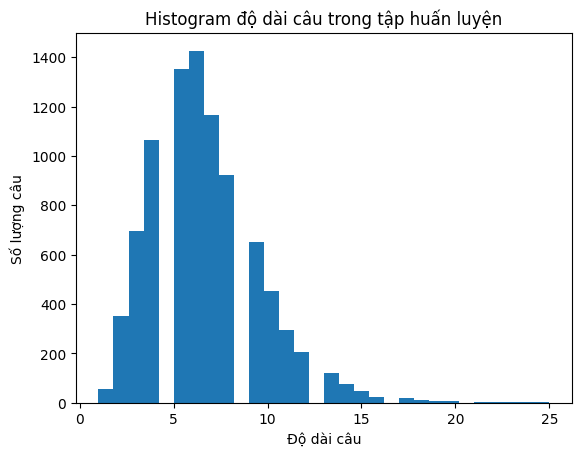

In [5]:
# Histogram độ dài câu trong tập huấn luyện
import matplotlib.pyplot as plt
lengths = df_train['text'].apply(lambda x: len(x.split()))
plt.hist(lengths, bins=30)
plt.xlabel('Độ dài câu')
plt.ylabel('Số lượng câu')
plt.title('Histogram độ dài câu trong tập huấn luyện')
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences 
from tensorflow.keras.layers import Embedding, LSTM
from tensorflow.keras.callbacks import EarlyStopping

# 1. Tokenization và padding
vocab_size = 5000
max_len = 20
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<UNK>')
tokenizer.fit_on_texts(df_train['text'])

def texts_to_padded_sequences(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
    return padded_sequences
X_train_seq = texts_to_padded_sequences(df_train['text'])
X_val_seq = texts_to_padded_sequences(df_val['text'])
X_test_seq = texts_to_padded_sequences(df_test['text'])

# 2. Embedding matrix tu Word2Vec
embedding_dim = w2v_model.vector_size
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]
# 3. Xây dựng mô hình với Embedding pre-trained + LSTM
lstm_pretrained_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=False),
    LSTM(128, dropout=0.5, recurrent_dropout=0.2),
    Dense(num_classes, activation='softmax')
])
# 4. Compile & huấn luyện mô hình voi EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lstm_pretrained_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_pretrained_model.fit(X_train_seq, df_train['category_enc'], epochs=30, batch_size=16,
                          validation_data=(X_val_seq, df_val['category_enc']), callbacks=[early_stop])

# 5. Đánh giá mô hình
y_pred = np.argmax(lstm_pretrained_model.predict(X_test_seq), axis=1)
f1_macro = f1_score(df_test['category_enc'], y_pred, average='macro')
print("Embedding Pre-trained + LSTM F1 Macro:", f1_macro)

Epoch 1/30


d:\NLP_DL\env\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


560/560 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.2101 - loss: 2.9178 - val_accuracy: 0.4247 - val_loss: 1.9018
Epoch 2/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.4366 - loss: 1.8995 - val_accuracy: 0.6069 - val_loss: 1.2967
Epoch 3/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.5740 - loss: 1.4573 - val_accuracy: 0.7249 - val_loss: 0.9973
Epoch 4/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.6526 - loss: 1.1982 - val_accuracy: 0.7602 - val_loss: 0.8521
Epoch 5/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.6987 - loss: 1.0372 - val_accuracy: 0.7807 - val_loss: 0.7578
Epoch 6/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.7255 - loss: 0.9242 - val_accuracy: 0.7955 - val_loss: 0.7053
Epoch 7/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.7486 - loss: 0.8515 - val_accuracy: 0.8095 - val_loss: 0.6688
Epoch 8/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7612 - loss: 0.8031 - val_accurac

## 3. Embedding học từ đầu + LSTM 

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

lstm_scratch_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, input_length=max_len),
    LSTM(128, dropout=0.5, recurrent_dropout=0.2),
    Dense(num_classes, activation='softmax')
])

lstm_scratch_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_scratch_model.fit(X_train_seq, df_train['category_enc'], epochs=20, batch_size=16,
                 validation_data=(X_val_seq, df_val['category_enc']), callbacks=[early_stop])

# Đánh giá
y_pred = np.argmax(lstm_scratch_model.predict(X_test_seq), axis=1)
f1_macro = f1_score(df_test['category_enc'], y_pred, average='macro')
print("Embedding Scratch + LSTM F1 Macro:", f1_macro)


Epoch 1/20


d:\NLP_DL\env\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


560/560 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.0474 - loss: 3.8430 - val_accuracy: 0.1561 - val_loss: 3.0946
Epoch 2/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.1786 - loss: 2.8332 - val_accuracy: 0.3457 - val_loss: 2.2231
Epoch 3/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.3495 - loss: 2.0892 - val_accuracy: 0.4730 - val_loss: 1.6752
Epoch 4/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - accuracy: 0.5101 - loss: 1.5608 - val_accuracy: 0.6580 - val_loss: 1.2581
Epoch 5/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.6409 - loss: 1.1661 - val_accuracy: 0.7342 - val_loss: 1.0051
Epoch 6/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.7312 - loss: 0.8929 - val_accuracy: 0.7491 - val_loss: 0.8911
Epoch 7/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.7933 - loss: 0.7106 - val_accuracy: 0.7816 - val_loss: 0.8273
Epoch 8/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - accuracy: 0.8349 - loss: 0.5696 - val_accurac

## 5. Đánh giá, so sánh và phân tích 

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.metrics import f1_score

# 1. TF-IDF + Logistic Regression
start = time.time()
y_pred_tfidf = tfidf_lr_pipeline.predict(df_test['text'])
inference_tfidf = (time.time() - start) / len(df_test)
f1_tfidf = f1_score(df_test['category_enc'], y_pred_tfidf, average='macro')
loss_tfidf = None  # scikit-learn không có test loss

# 2. Word2Vec (Avg) + Dense
start = time.time()
y_pred_w2v = np.argmax(model.predict(X_test_avg, verbose=0), axis=1)
inference_w2v = (time.time() - start) / len(df_test)
f1_w2v = f1_score(df_test['category_enc'], y_pred_w2v, average='macro')
loss_w2v, _ = model.evaluate(X_test_avg, df_test['category_enc'], verbose=0)

# 3. Embedding (Pre-trained) + LSTM
start = time.time()
y_pred_pre = np.argmax(lstm_pretrained_model.predict(X_test_seq, verbose=0), axis=1)
inference_pre = (time.time() - start) / len(df_test)
f1_pre = f1_score(df_test['category_enc'], y_pred_pre, average='macro')
loss_pre, _ = lstm_pretrained_model.evaluate(X_test_seq, df_test['category_enc'], verbose=0)

# 4. Embedding (Scratch) + LSTM
start = time.time()
y_pred_scratch = np.argmax(lstm_scratch_model.predict(X_test_seq, verbose=0), axis=1)
inference_scratch = (time.time() - start) / len(df_test)
f1_scratch = f1_score(df_test['category_enc'], y_pred_scratch, average='macro')
loss_scratch, _ = lstm_scratch_model.evaluate(X_test_seq, df_test['category_enc'], verbose=0)

# 5. Tạo bảng kết quả
results = pd.DataFrame({
    "Pipeline": [
        "TF-IDF + Logistic Regression",
        "Word2Vec (Avg) + Dense",
        "Embedding (Pre-trained) + LSTM",
        "Embedding (Scratch) + LSTM"
    ],
    "F1-score (Macro)": [f1_tfidf, f1_w2v, f1_pre, f1_scratch],
    "Test Loss": [loss_tfidf, loss_w2v, loss_pre, loss_scratch],
    "Inference Time (s/sample)": [inference_tfidf, inference_w2v, inference_pre, inference_scratch]
})

print("\nBảng tổng hợp kết quả đánh giá:")
print(results.round(6))


🔹 Bảng tổng hợp kết quả đánh giá:
                         Pipeline  F1-score (Macro)  Test Loss  \
0    TF-IDF + Logistic Regression          0.835298        NaN   
1          Word2Vec (Avg) + Dense          0.793532   0.714392   
2  Embedding (Pre-trained) + LSTM          0.829596   0.622635   
3      Embedding (Scratch) + LSTM          0.830693   0.842276   

   Inference Time (s/sample)  
0                   0.000011  
1                   0.000101  
2                   0.000272  
3                   0.000330  


In [ ]:
texts = ["i do not want to use the socket anymore", 
        "is it going to be sunny or rainy tomorrow",
        "tell me the preparation method for chicken sixty five"]
intent = le.transform(["iot_wemo_off", "weather_query", "cooking_recipe"]) 


# TF-IDF + Logistic Regression
pred_tfidf = tfidf_lr_pipeline.predict(texts)
prob_tfidf = tfidf_lr_pipeline.predict_proba(texts)


X_examples_avg = np.array([sentence_to_avg_vector(text, w2v_model) for text in texts])
prob_w2v = model.predict(X_examples_avg, verbose=0)
pred_w2v = np.argmax(prob_w2v, axis=1)


seq_examples = tokenizer.texts_to_sequences(texts)
X_examples_seq = pad_sequences(seq_examples, maxlen=max_len, padding='post', truncating='post')

prob_pre = lstm_pretrained_model.predict(X_examples_seq, verbose=0)
pred_pre = np.argmax(prob_pre, axis=1)

# Embedding (Scratch) + LSTM
prob_scratch = lstm_scratch_model.predict(X_examples_seq, verbose=0)
pred_scratch = np.argmax(prob_scratch, axis=1)



In [32]:
df_results = pd.DataFrame({
    "Câu": texts,
    "Nhãn thật": le.inverse_transform(intent),
    "TF-IDF + LR": le.inverse_transform(pred_tfidf),
    "Word2Vec + Dense": le.inverse_transform(pred_w2v),
    "LSTM (Pre-trained)": le.inverse_transform(pred_pre),
    "LSTM (Scratch)": le.inverse_transform(pred_scratch)
})

print("\nKết quả dự đoán của 4 mô hình:")
print(df_results)


Kết quả dự đoán của 4 mô hình:
                                                 Câu       Nhãn thật  \
0            i do not want to use the socket anymore    iot_wemo_off   
1          is it going to be sunny or rainy tomorrow   weather_query   
2  tell me the preparation method for chicken six...  cooking_recipe   

      TF-IDF + LR   Word2Vec + Dense LSTM (Pre-trained)  LSTM (Scratch)  
0  cooking_recipe  audio_volume_mute       iot_wemo_off     iot_wemo_on  
1   weather_query      weather_query      weather_query   weather_query  
2  cooking_recipe           qa_maths     cooking_recipe  general_quirky  
